## Script to crop full Cerra dataset to our domain 

In [ ]:
import xarray as xr 
from anemoi.datasets import open_dataset
import numpy as np
import yaml
import os 
import cfgrib
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pathlibj
import csv


In [3]:
DATA_DIR = pathlib.Path("/mnt/weatherloss/WindPower/data")
RAW_GRIB_DIR = DATA_DIR / "cerra_boz" / "raw_grib"
OUT_DIR = DATA_DIR / "NorthSea" / "cerradata"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
LAT_MIN, LAT_MAX = 49, 59.0
LON_MIN, LON_MAX = -6, 12.0  # adjust to your domain

def index_box(ds, lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX):
    lat = ds["latitude"].values
    lon = ds["longitude"].values
    if np.any(lon > 180):
        lon = ((lon + 180) % 360) - 180  # wrap 0–360 -> -180..180
    if lat_min > lat_max: lat_min, lat_max = lat_max, lat_min
    if lon_min > lon_max: lon_min, lon_max = lon_max, lon_min
    mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    if not np.any(mask):
        raise ValueError("No grid points in specified box.")
    yy, xx = np.where(mask)
    return slice(int(yy.min()), int(yy.max()) + 1), slice(int(xx.min()), int(xx.max()) + 1)

def open_all_messages(path):
    # indexpath="" forces cfgrib to ignore stale .idx files
    return cfgrib.open_datasets(path, backend_kwargs={"decode_timedelta": True, "indexpath": ""})

In [7]:
month = "2022_01"
pressure_path = next(RAW_GRIB_DIR.glob(f"*pressure_{month}*.grib"))
height_path   = next(RAW_GRIB_DIR.glob(f"*height_{month}*.grib"))
single_path   = next(RAW_GRIB_DIR.glob(f"*single_{month}*.grib"))
static_path   = RAW_GRIB_DIR / "cerra_static.grib"

pressure_msgs = open_all_messages(pressure_path)
height_msgs   = open_all_messages(height_path)
single_msgs   = open_all_messages(single_path)
static_msgs   = open_all_messages(static_path)

ys, xs = index_box(pressure_msgs[0])

def crop_and_merge(msgs):
    cropped = []
    for ds in msgs:
        dsc = ds.isel(y=ys, x=xs)
        if "heightAboveGround" in dsc.coords and dsc.coords["heightAboveGround"].size == 1:
            dsc = dsc.reset_coords("heightAboveGround", drop=True).squeeze()
        cropped.append(dsc)
    aligned = xr.align(*cropped, join="inner")
    return xr.merge(aligned, compat="override", combine_attrs="drop")

ds_pressure = crop_and_merge(pressure_msgs)
ds_height   = crop_and_merge(height_msgs)
ds_single   = crop_and_merge(single_msgs)
ds_static   = crop_and_merge(static_msgs)

ds_all = xr.merge([ds_pressure, ds_height, ds_single, ds_static], compat="override", combine_attrs="drop")
ds_all


/opt/conda/envs/windpower312/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/conda/envs/windpower312/lib/python3.12/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/conda

<xarray.Dataset> Size: 3GB
Dimensions:            (time: 248, isobaricInhPa: 9, y: 217, x: 237,
                        heightAboveGround: 4)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2022-01-01 ... 2022-01-31T21...
  * isobaricInhPa      (isobaricInhPa) float64 72B 1e+03 950.0 ... 600.0 500.0
  * heightAboveGround  (heightAboveGround) float64 32B 50.0 100.0 150.0 200.0
    step               timedelta64[ns] 8B 00:00:00
    latitude           (y, x) float64 411kB 48.17 48.18 48.19 ... 59.56 59.56
    longitude          (y, x) float64 411kB 354.3 354.4 354.4 ... 12.91 13.0
    valid_time         (time) datetime64[ns] 2kB 2022-01-01 ... 2022-01-31T21...
    entireAtmosphere   float64 8B 0.0
    meanSea            float64 8B 0.0
    surface            float64 8B 0.0
Dimensions without coordinates: y, x
Data variables: (12/14)
    z                  (time, isobaricInhPa, y, x) float32 459MB ...
    t                  (time, isobaricInhPa, y, x) float32 459MB ...
    u                  (time, isobaricInhPa, y, x) float32 459MB ...
    v                  (time, isobaricInhPa, y, x) float32 459MB ...
    r                  (time, isobaricInhPa, y, x) float32 459MB ...
    ws                 (time, heightAboveGround, y, x) float32 204MB ...
    ...                 ...
    t2m                (time, y, x) float32 51MB ...
    si10               (time, y, x) float32 51MB ...
    wdir10             (time, y, x) float32 51MB ...
    msl                (time, y, x) float32 51MB ...
    lsm                (y, x) float32 206kB ...
    orog               (y, x) float32 206kB ...

In [ ]:
#ds_all=xr.open_dataset("cerra_2022_01.zarr")
#ds_all.longitude.values

FileNotFoundError: No such file or directory: '/mnt/weatherloss/WindPower/data/NorthSea/Cerra/cerra_2022_01.zarr'

Text(0.5, 1.0, 'CERRA with wind farm locations')

/opt/conda/envs/windpower312/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


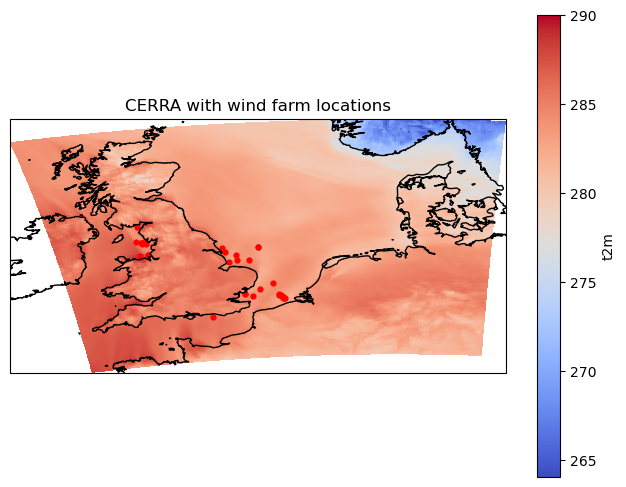

In [10]:

meta_path = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv")
farms = []
with meta_path.open('r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        lat = float(row['lat'])
        lon = float(row['lon'])
        farms.append((lat, lon))

lats, lons = zip(*farms)

# Select t2m and a random time slice
t2m = ds_all['t2m']
if 'time' in t2m.dims:
    t_idx = np.random.randint(t2m.sizes['time'])
    data_var = t2m.isel(time=t_idx)
    timestamp = str(t2m['time'].isel(time=t_idx).values)
else:
    data_var = t2m
    timestamp = 'static'

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
data_var.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm', x='longitude', y='latitude')
ax.scatter(lons, lats, color='red', s=12, transform=ccrs.PlateCarree())
ax.coastlines()
ax.set_title(f'CERRA with wind farm locations')


In [3]:
outer=xr.open_dataset("cerra_outer.zarr")
inner = xr.open_dataset("cerra_inner2.zarr")

Text(0.5, 1.0, 't2m outer vs inner @ static')

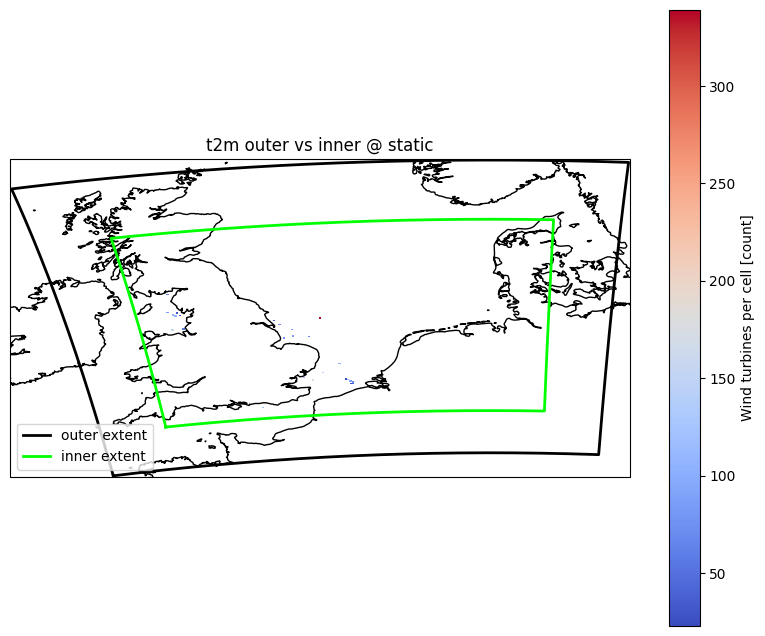

In [11]:
# Plot outer vs inner extent with a random t2m slice and wind farms
var_name = 'turbines'
outer_da = outer[var_name]
inner_da = inner[var_name]

# Pick a random time index (shared time dimension) if present
if 'time' in outer_da.dims:
    t_idx = np.random.randint(outer_da.sizes['time'])
    outer_slice = outer_da.isel(time=t_idx)
    inner_slice = inner_da.isel(time=t_idx)
    timestamp = str(outer_da['time'].isel(time=t_idx).values)
else:
    outer_slice = outer_da
    inner_slice = inner_da
    timestamp = 'static'

def _outline_coords(ds):
    lat = ds['latitude'].values
    lon = ds['longitude'].values
    edge_lat = np.concatenate([lat[0, :], lat[:, -1], lat[-1, ::-1], lat[::-1, 0]])
    edge_lon = np.concatenate([lon[0, :], lon[:, -1], lon[-1, ::-1], lon[::-1, 0]])
    return edge_lon, edge_lat

out_lon, out_lat = _outline_coords(outer_slice)
in_lon, in_lat = _outline_coords(inner_slice)

# Adjust turbine longitudes to match dataset convention (0..360 if needed)
farm_lons_plot = np.array(lons)
lon_max_val = np.nanmax(outer_slice['longitude'].values)
if lon_max_val > 180:
    farm_lons_plot = np.where(farm_lons_plot < 0, farm_lons_plot + 360, farm_lons_plot)

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
outer_slice.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm', x='longitude', y='latitude')
ax.plot(out_lon, out_lat, color='black', linewidth=2, transform=ccrs.PlateCarree(), label='outer extent')
ax.plot(in_lon, in_lat, color='lime', linewidth=2, transform=ccrs.PlateCarree(), label='inner extent')
#ax.scatter(farm_lons_plot, lats, color='yellow', edgecolor='k', s=18, transform=ccrs.PlateCarree(), label='wind farms')
ax.coastlines()
ax.legend(loc='lower left')
ax.set_title(f"t2m outer vs inner @ {timestamp}")
